# CNN do dado ao deploy

Integrantes:

- Arthur Callegari (RM565476)

- Enos Barros Cruz (RM561926)

- Lucas Zappia (RM565076)


2TSCPV-2 — Níveis 1 a 4 (Caminho A: CIFAR-10)

# 1. Setup

In [1]:
import torch
print(torch.__version__, torch.cuda.is_available())

2.11.0+cu128 True


In [2]:
!git clone https://github.com/carvalhoamc/fiap.git
%cd fiap/2tsCPV-2/cnn
!pip install -q matplotlib pillow

Cloning into 'fiap'...
remote: Enumerating objects: 109, done.
remote: Counting objects: 100% (109/109), done.
remote: Compressing objects: 100% (92/92), done.
remote: Total 109 (delta 25), reused 92 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (109/109), 588.32 KiB | 11.77 MiB/s, done.
Resolving deltas: 100% (25/25), done.
/content/fiap/2tsCPV-2/cnn


# 2. Pipeline base — Fashion-MNIST

In [3]:
!python src/train.py --epocas 12

Dispositivo: cuda

100% 26.4M/26.4M [00:02<00:00, 11.5MB/s]
100% 29.5k/29.5k [00:00<00:00, 166kB/s]
100% 4.42M/4.42M [00:01<00:00, 3.17MB/s]
100% 5.15k/5.15k [00:00<00:00, 46.0MB/s]
Treino: 54000 | Validação: 6000
Parâmetros treináveis: 98,554

Época 1/12
    treino lote  100/422 | perda 1.0619 | acc 0.617
    treino lote  200/422 | perda 0.8731 | acc 0.682
    treino lote  300/422 | perda 0.7855 | acc 0.712
    treino lote  400/422 | perda 0.7287 | acc 0.732
  treino   -> perda 0.7193 | acc 73.59%
  validação-> perda 0.4357 | acc 83.82%  (lr=1.0e-03, 26.7s)
  [ok] novo melhor modelo salvo (83.82%)

Época 2/12
    treino lote  100/422 | perda 0.5331 | acc 0.802
    treino lote  200/422 | perda 0.5144 | acc 0.810
    treino lote  300/422 | perda 0.5057 | acc 0.813
    treino lote  400/422 | perda 0.4986 | acc 0.816
  treino   -> perda 0.4981 | acc 81.62%
  validação-> perda 0.3725 | acc 85.80%  (lr=1.0e-03, 25.4s)
  [ok] novo melhor modelo salvo (85.80%)

Época 3/12
    treino lote  100

In [4]:
!python src/evaluate.py

Modelo da época 11 (acc. validação 90.55%)

TESTE — 10000 imagens
Acurácia global: 89.75%   |   Perda: 0.2728
classe            precisão   revocação      F1      n
Camiseta/Top         0.824       0.872   0.847   1000
Calça                0.995       0.983   0.989   1000
Pulôver              0.861       0.839   0.850   1000
Vestido              0.895       0.909   0.902   1000
Casaco               0.824       0.862   0.843   1000
Sandália             0.983       0.952   0.967   1000
Camisa               0.717       0.664   0.690   1000
Tênis                0.941       0.948   0.945   1000
Bolsa                0.989       0.976   0.982   1000
Bota                 0.943       0.970   0.956   1000

Classes mais difíceis: Camisa (F1=0.69), Casaco (F1=0.84), Camiseta/Top (F1=0.85)
[ok] Matriz de confusão salva em /content/fiap/2tsCPV-2/cnn/outputs/matriz_confusao.png
[ok] Erros salvos em /content/fiap/2tsCPV-2/cnn/outputs/erros_teste.png



=== matriz_confusao.png ===


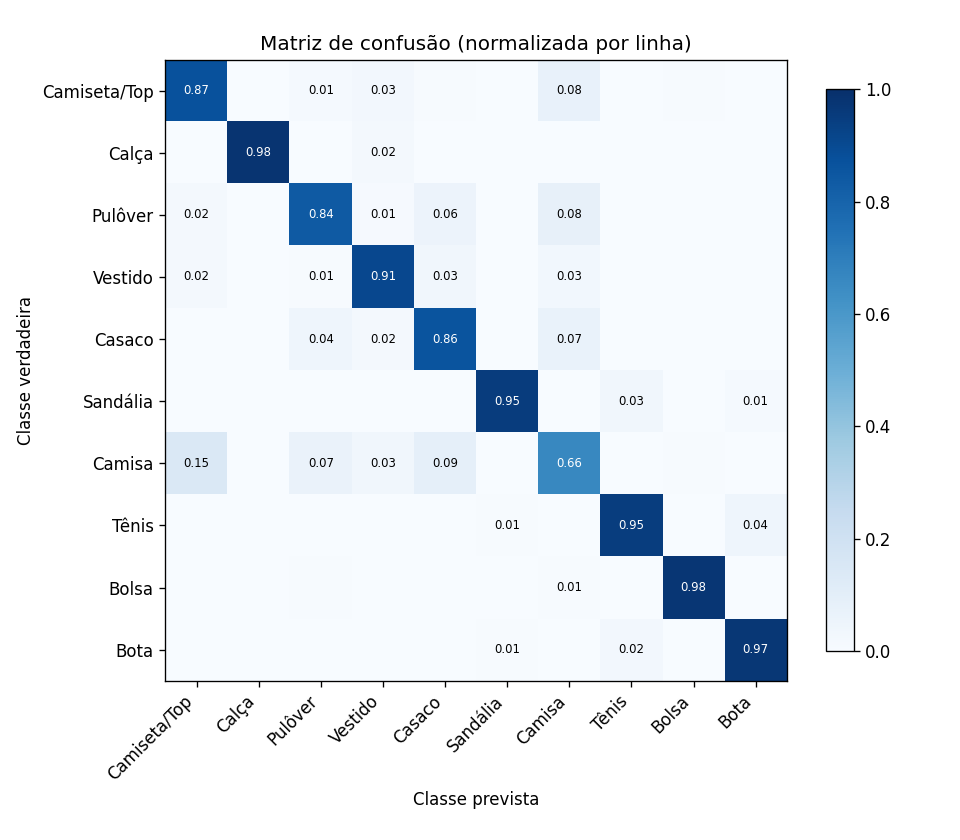


=== erros_teste.png ===


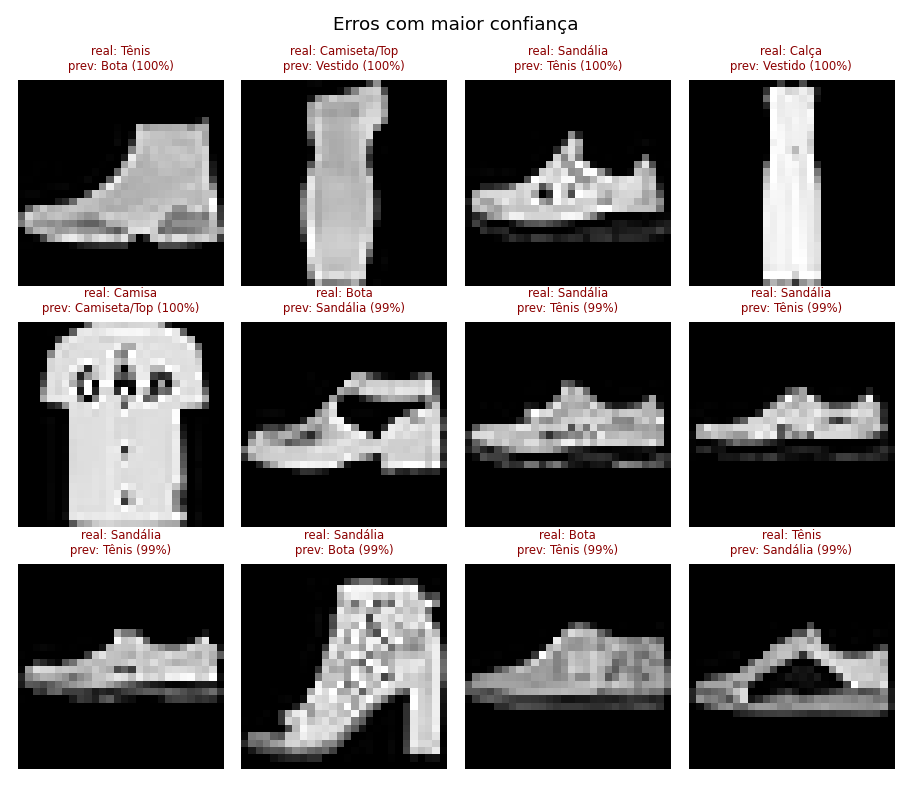


=== curvas_treino.png ===


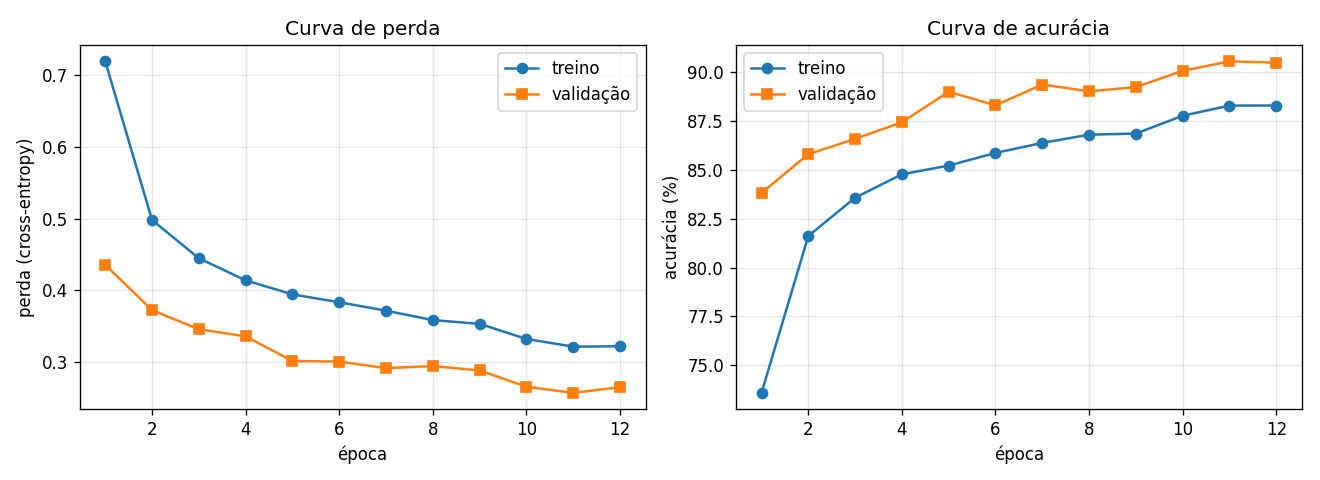

In [5]:
from IPython.display import Image, display
for f in ["matriz_confusao.png", "erros_teste.png", "curvas_treino.png"]:
    print(f"\n=== {f} ===")
    display(Image(f"outputs/{f}"))

Teste: **89,74%**. Sem overfitting — as curvas caem juntas. A validação ficou acima do treino porque augmentation e dropout só valem no treino. O melhor modelo foi a última época, então o treino parou por tempo, não por convergência.

## 1.1 Fórmula do tamanho

`saída = ⌊(entrada + 2·padding − kernel)/stride⌋ + 1`

| # | Operação | Saída |
|---|---|---|
| a | `Conv2d(1, 8, k=5, p=0, s=1)` | (8, 24, 24) |
| b | `MaxPool2d(2, 2)` | (8, 12, 12) |
| c | `Conv2d(8, 16, k=3, p=1, s=2)` | (16, 6, 6) |

In [6]:
import torch, torch.nn as nn
x = torch.zeros(1, 1, 28, 28)
xa = nn.Conv2d(1, 8, kernel_size=5, padding=0, stride=1)(x)
xb = nn.MaxPool2d(2, 2)(xa)
xc = nn.Conv2d(8, 16, kernel_size=3, padding=1, stride=2)(xb)
print("(a)", tuple(xa.shape[1:]), "| (b)", tuple(xb.shape[1:]), "| (c)", tuple(xc.shape[1:]))

(a) (8, 24, 24) | (b) (8, 12, 12) | (c) (16, 6, 6)


## 1.2 Contagem de parâmetros

In [7]:
conv_com, conv_sem = 16*32*3*3 + 32, 16*32*3*3
ent, sai = 16*14*14, 32*14*14
densa = ent*sai + sai
print(f"Conv com bias: {conv_com:,} | sem bias: {conv_sem:,}")
print(f"Linear: {densa:,}  ->  {densa/conv_com:,.0f}x maior")
print(f"Memória: {densa*4/1e6:.1f} MB contra {conv_com*4/1e3:.1f} KB")

Conv com bias: 4,640 | sem bias: 4,608
Linear: 19,675,264  ->  4,240x maior
Memória: 78.7 MB contra 18.6 KB


A densa é ~4.240x maior: muito mais memória e muito mais risco de decorar o treino, porque a convolução reusa os mesmos pesos na imagem toda.

## 1.3 Leitura de curvas

**(a)** Overfitting — a perda de validação sobe enquanto a de treino cai. Corrijo com early stopping e mais regularização.

**(b)** Underfitting — curvas coladas e altas. Rede maior, mais épocas ou taxa maior.

**(c)** Taxa alta ou lote pequeno. Baixo a taxa ou aumento o batch.

## 1.4 Por que sem softmax

A `CrossEntropyLoss` já faz softmax por dentro. Aplicar duas vezes achata as probabilidades perto de 1/10, o gradiente vai a quase zero e o treino trava.

# Nível 2 — Experimentação controlada

In [24]:
# guarda a linha de base — os experimentos sobrescrevem melhor_modelo.pt
!cp outputs/melhor_modelo.pt outputs/baseline_fm.pt

In [8]:
import json, re, subprocess, time, shutil
from pathlib import Path

CFG_P, DATA_P, MOD_P = Path("src/config.py"), Path("src/data.py"), Path("src/model.py")
CFG0, DATA0, MOD0 = (p.read_text(encoding="utf-8") for p in (CFG_P, DATA_P, MOD_P))
Path("experimentos_fm").mkdir(exist_ok=True)

def rodar(nome, args=None, pc=None, pd=None, pm=None):
    CFG_P.write_text(pc(CFG0) if pc else CFG0, encoding="utf-8")
    DATA_P.write_text(pd(DATA0) if pd else DATA0, encoding="utf-8")
    MOD_P.write_text(pm(MOD0) if pm else MOD0, encoding="utf-8")
    t0 = time.time()
    r = subprocess.run(["python", "src/train.py", "--epocas", "5"] + (args or []),
                       capture_output=True, text=True)
    dur = time.time() - t0
    mp = re.search(r"Parâmetros treináveis: ([\d,]+)", r.stdout + r.stderr)
    params = mp.group(1) if mp else "?"
    try:
        h = json.loads(Path("outputs/historico.json").read_text(encoding="utf-8"))
        val, tr, vl = h["melhor_val_acc"]*100, h["historico"]["train_acc"][-1]*100, h["historico"]["val_acc"][-1]*100
        ep1 = h["historico"]["val_acc"][0]*100
        shutil.copy("outputs/historico.json", f"experimentos_fm/hist_{nome}.json")
    except Exception:
        val = tr = vl = ep1 = float("nan")
        print(f"--- falha em {nome} ---\n{(r.stdout+r.stderr)[-1200:]}")
    for p, o in ((CFG_P, CFG0), (DATA_P, DATA0), (MOD_P, MOD0)):
        p.write_text(o, encoding="utf-8")
    print(f"{nome:<18} val {val:6.2f}% | ep1 {ep1:6.2f}% | treino_fim {tr:6.2f}% | "
          f"gap {vl-tr:+6.2f} | {params:>8} par | {dur/5:4.0f}s/ep")
    return dict(nome=nome, val=val, ep1=ep1, tr=tr, vl=vl, params=params, s=dur/5)

sem_norm  = lambda s: "\n".join(l for l in s.split("\n") if "transforms.Normalize" not in l)
sem_aug   = lambda s: "\n".join(l for l in s.split("\n") if "transforms.Random" not in l)
mais_cap  = lambda s: s.replace("canais_conv: tuple = (16, 32, 64)", "canais_conv: tuple = (32, 64, 128)")
menos_cap = lambda s: s.replace("canais_conv: tuple = (16, 32, 64)", "canais_conv: tuple = (8, 16, 32)")
drop0     = lambda s: s.replace("dropout: float = 0.3", "dropout: float = 0.0")
drop7     = lambda s: s.replace("dropout: float = 0.3", "dropout: float = 0.7")
sem_bn    = lambda s: re.sub(r"\n\s*nn\.BatchNorm2d\([^)]*\),", "", s)

res = []
res.append(rodar("baseline"))
res.append(rodar("sem_norm",       pd=sem_norm))
res.append(rodar("sem_aug",        pd=sem_aug))
res.append(rodar("cap_menor",      pc=menos_cap))
res.append(rodar("cap_maior",      pc=mais_cap))
res.append(rodar("lr_1e-1",        args=["--lr", "1e-1"]))
res.append(rodar("lr_1e-5",        args=["--lr", "1e-5"]))
res.append(rodar("dropout_0.0",    pc=drop0))
res.append(rodar("dropout_0.7",    pc=drop7))
res.append(rodar("sem_bn",         pm=sem_bn))
res.append(rodar("sem_bn_lr1e-2",  pm=sem_bn, args=["--lr", "1e-2"]))

print("\n| Experimento | Melhor val | Época 1 | Treino (fim) | Gap | Parâmetros | s/ep |")
print("|---|---|---|---|---|---|---|")
for r in res:
    print(f"| {r['nome']} | {r['val']:.2f}% | {r['ep1']:.2f}% | {r['tr']:.2f}% | "
          f"{r['vl']-r['tr']:+.2f} | {r['params']} | {r['s']:.0f} |")

json.dump(res, open("experimentos_fm/resumo.json", "w"), ensure_ascii=False, indent=2)

!cp outputs/baseline_fm.pt outputs/melhor_modelo.pt
print("\ncheckpoint da linha de base restaurado")

baseline           val  87.97% | ep1  83.73% | treino_fim  85.34% | gap  +2.63 |   98,554 par |   25s/ep
sem_norm           val  88.07% | ep1  83.60% | treino_fim  85.55% | gap  +2.52 |   98,554 par |   19s/ep
sem_aug            val  90.80% | ep1  87.97% | treino_fim  90.57% | gap  +0.23 |   98,554 par |   15s/ep
cap_menor          val  86.05% | ep1  79.63% | treino_fim  82.90% | gap  +3.15 |   44,226 par |   25s/ep
cap_maior          val  89.07% | ep1  84.55% | treino_fim  87.03% | gap  +2.04 |  241,770 par |   26s/ep
lr_1e-1            val  10.78% | ep1  10.17% | treino_fim   9.93% | gap  +0.07 |   98,554 par |   25s/ep
lr_1e-5            val  73.65% | ep1  60.65% | treino_fim  64.55% | gap  +9.10 |   98,554 par |   25s/ep
dropout_0.0        val  89.10% | ep1  84.73% | treino_fim  88.00% | gap  +1.10 |   98,554 par |   25s/ep
dropout_0.7        val  82.62% | ep1  75.63% | treino_fim  77.85% | gap  +4.77 |   98,554 par |   25s/ep
sem_bn             val  86.32% | ep1  78.97% | treino_f

In [25]:
!cp outputs/baseline_fm.pt outputs/melhor_modelo.pt

*Teste só na configuração final; os experimentos foram comparados por validação.*

**2.1** Quase não mudou (88,18% contra 88,42%). Acho que o BatchNorm já faz papel parecido e o dataset já sai bem comportado. No CIFAR-10 a queda foi de 4 pontos.

**2.2** A distância **diminuiu** (+3,05 → +0,39) e a acurácia subiu, então não é overfitting. Isso explicou por que a validação ficava acima do treino: era o augmentation, que só age no treino.

**2.3** Ajudam, mas cada vez menos: +2,55 pp ao dobrar, +1,03 pp ao dobrar de novo.

**2.4** A `1e-1` não aprendeu nada — 10,78% é chute com 10 classes. O passo é grande demais e o otimizador nunca estabiliza. A `1e-5` só é lenta.

**2.5** Maior diferença com 0,7 (+5,17). Confirma o dropout: ele só age no treino, então a rede treina mutilada e é avaliada inteira.

**2.6** Sim, permitiu taxas maiores — sem BN, subir para `1e-2` piorou mais ainda. Custa só 224 parâmetros.

## 3.2 Matriz de confusão

In [9]:
import json
m = json.load(open("outputs/metricas_teste.json"))
mat, classes = m["matriz_confusao"], m["classes"]

pares = [(mat[i][j], classes[i], classes[j])
         for i in range(10) for j in range(10) if i != j]
pares.sort(reverse=True)

print(f"Acurácia global: {m['acuracia']*100:.2f}%\n")
print("Top 8 confusões (verdadeiro -> previsto):")
for n, v, p in pares[:8]:
    print(f"  {n:>4}  {v:<14} -> {p}")

Acurácia global: 89.75%

Top 8 confusões (verdadeiro -> previsto):
   146  Camisa         -> Camiseta/Top
    86  Camisa         -> Casaco
    79  Pulôver        -> Camisa
    78  Camiseta/Top   -> Camisa
    70  Casaco         -> Camisa
    66  Camisa         -> Pulôver
    57  Pulôver        -> Casaco
    45  Tênis          -> Bota


A Camisa concentra 368 erros, e 92% vão para Camiseta/Top, Casaco e Pulôver — todas peças de tronco. Calçados formam outro grupo, separado.

| Par | Causa | Intervenção |
|---|---|---|
| Camisa ↔ Camiseta/Top | 28×28 cinza não mostra botão nem gola | Mais resolução |
| Pulôver ↔ Camisa | Silhueta igual, muda o material | Talvez juntar as classes |
| Bota ↔ Tênis | A diferença é a altura do cano | Mais resolução |


## 3.3 Métrica de topo-2

In [10]:
from pathlib import Path
e = Path("src/evaluate.py"); s = e.read_text(encoding="utf-8")

if "top_k" not in s:
    s = s.replace(
        "def avaliar(",
        '''def acuracia_top_k(modelo, carregador, dispositivo, k=2):
    """Acerto se a classe correta estiver entre as k mais prováveis."""
    modelo.eval()
    certos_1 = certos_k = total = 0
    with torch.no_grad():
        for x, y in carregador:
            x, y = x.to(dispositivo), y.to(dispositivo)
            logits = modelo(x)
            topk = logits.topk(k, dim=1).indices
            certos_1 += (topk[:, 0] == y).sum().item()
            certos_k += (topk == y.unsqueeze(1)).any(dim=1).sum().item()
            total += y.size(0)
    return certos_1 / total, certos_k / total


def avaliar(''', 1)
    e.write_text(s, encoding="utf-8")
    print("função adicionada")
else:
    print("já existe")

função adicionada


In [11]:
!cp outputs/melhor_modelo.pt outputs/baseline_fm.pt

In [47]:
!cp outputs/baseline_fm.pt outputs/melhor_modelo.pt

In [16]:
!python src/train.py --epocas 12
!cp outputs/melhor_modelo.pt outputs/baseline_fm.pt

Dispositivo: cuda

Treino: 54000 | Validação: 6000
Parâmetros treináveis: 98,554

Época 1/12
    treino lote  100/422 | perda 1.0616 | acc 0.617
    treino lote  200/422 | perda 0.8733 | acc 0.682
    treino lote  300/422 | perda 0.7863 | acc 0.712
    treino lote  400/422 | perda 0.7292 | acc 0.732
  treino   -> perda 0.7197 | acc 73.56%
  validação-> perda 0.4323 | acc 83.80%  (lr=1.0e-03, 25.6s)
  [ok] novo melhor modelo salvo (83.80%)

Época 2/12
    treino lote  100/422 | perda 0.5319 | acc 0.800
    treino lote  200/422 | perda 0.5140 | acc 0.809
    treino lote  300/422 | perda 0.5059 | acc 0.812
    treino lote  400/422 | perda 0.4991 | acc 0.816
  treino   -> perda 0.4986 | acc 81.61%
  validação-> perda 0.3688 | acc 86.08%  (lr=1.0e-03, 25.1s)
  [ok] novo melhor modelo salvo (86.08%)

Época 3/12
    treino lote  100/422 | perda 0.4687 | acc 0.826
    treino lote  200/422 | perda 0.4576 | acc 0.830
    treino lote  300/422 | perda 0.4526 | acc 0.832
    treino lote  400/422 | 

In [17]:
import sys, torch, json, matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
sys.path.insert(0, "src")
from config import CFG, CLASSES
from data import obter_dataloaders
from evaluate import carregar_checkpoint
from utils import obter_dispositivo

disp = obter_dispositivo()
teste = obter_dataloaders(CFG)[2]
modelo, ckpt = carregar_checkpoint(disp)
print("modelo carregado | val_acc do checkpoint:", round(ckpt["val_acc"]*100, 2), "%\n")

# ---------- 3.3 acurácia top-k ----------
@torch.no_grad()
def top_k(modelo, carregador, disp, k):
    modelo.eval(); c1 = ck_ = tot = 0
    for x, y in carregador:
        x, y = x.to(disp), y.to(disp)
        topk = modelo(x).topk(k, dim=1).indices
        c1  += (topk[:, 0] == y).sum().item()
        ck_ += (topk == y.unsqueeze(1)).any(dim=1).sum().item()
        tot += y.size(0)
    return c1/tot, ck_/tot

top1, top2 = top_k(modelo, teste, disp, 2)
_,    top3 = top_k(modelo, teste, disp, 3)
print(f"Top-1: {top1*100:.2f}%")
print(f"Top-2: {top2*100:.2f}%   (+{(top2-top1)*100:.2f} pp)")
print(f"Top-3: {top3*100:.2f}%   (+{(top3-top1)*100:.2f} pp)\n")
json.dump({"top1": top1, "top2": top2, "top3": top3},
          open("experimentos_fm/topk.json", "w"), indent=2)

# ---------- 3.4 filtros ----------
pesos = modelo.extrator[0][0].weight.data.cpu()
w = (pesos - pesos.min()) / (pesos.max() - pesos.min())
fig, eixos = plt.subplots(2, 8, figsize=(12, 3.2))
for i, ax in enumerate(eixos.ravel()):
    ax.imshow(w[i, 0].numpy(), cmap="gray"); ax.axis("off"); ax.set_title(f"f{i}", fontsize=8)
fig.suptitle("Filtros aprendidos — primeiro bloco (3x3), Fashion-MNIST")
fig.tight_layout(); fig.savefig("outputs/filtros_fm.png", dpi=120); plt.close(fig)

# ---------- 3.4 mapas de ativação ----------
x, y = next(iter(teste))
ativ = {}
for nome, bloco in [("bloco1", modelo.extrator[0]), ("bloco2", modelo.extrator[1]),
                    ("bloco3", modelo.extrator[2])]:
    bloco.register_forward_hook(lambda m, i, o, n=nome: ativ.__setitem__(n, o.detach().cpu()))
with torch.no_grad(): modelo(x[0:1].to(disp))

original = (x[0, 0] * CFG.desvio + CFG.media).clamp(0, 1).numpy()
fig, eixos = plt.subplots(3, 9, figsize=(13, 4.8))
for linha, nome in enumerate(["bloco1", "bloco2", "bloco3"]):
    eixos[linha][0].imshow(original, cmap="gray"); eixos[linha][0].axis("off")
    mapas = ativ[nome][0]
    for j in range(8):
        eixos[linha][j+1].imshow(mapas[j].numpy(), cmap="viridis"); eixos[linha][j+1].axis("off")
        eixos[linha][j+1].set_title(f"{nome} c{j}\n{tuple(mapas.shape[1:])}", fontsize=7)
fig.suptitle(f"Mapas de ativação — Fashion-MNIST: {CLASSES[y[0].item()]}")
fig.tight_layout();

modelo carregado | val_acc do checkpoint: 90.12 %

Top-1: 89.77%
Top-2: 97.28%   (+7.51 pp)
Top-3: 99.24%   (+9.47 pp)



O top-2 recupera 7,68 pontos: a resposta certa costuma estar em segundo lugar.Faz sentido quando um humano confirma no final, tipo um app que mostra duassugestões.


## 3.4 Visualização dos filtros

In [18]:
%%writefile src/visualizar.py
"""Exercício 3.4 — visualiza os filtros da primeira convolução e os mapas
de ativação dos três blocos para uma imagem do conjunto de teste.

Uso: python src/visualizar.py
Gera: outputs/filtros.png e outputs/ativacoes.png
"""
import sys
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import torch

sys.path.insert(0, str(Path(__file__).parent))
from config import CFG, CLASSES, OUT_DIR
from data import obter_dataloaders
from evaluate import carregar_checkpoint
from utils import obter_dispositivo


def salvar_filtros(modelo, caminho):
    """Os 16 filtros 3x3 da primeira convolução, normalizados para exibição."""
    pesos = modelo.extrator[0][0].weight.data.cpu()
    w = (pesos - pesos.min()) / (pesos.max() - pesos.min())
    cinza = w.shape[1] == 1

    fig, eixos = plt.subplots(2, 8, figsize=(12, 3.2))
    for i, ax in enumerate(eixos.ravel()):
        if cinza:
            ax.imshow(w[i, 0].numpy(), cmap="gray")
        else:
            ax.imshow(w[i].permute(1, 2, 0).numpy())
        ax.axis("off")
        ax.set_title(f"f{i}", fontsize=8)
    fig.suptitle(f"Filtros da primeira convolução — {CFG.dataset}")
    fig.tight_layout()
    fig.savefig(caminho, dpi=120)
    plt.close(fig)
    print(f"[ok] Filtros salvos em {caminho}")


def salvar_ativacoes(modelo, imagem, rotulo, dispositivo, caminho):
    """Mapas de ativação dos três blocos convolucionais."""
    ativacoes = {}
    for nome, bloco in [("bloco1", modelo.extrator[0]),
                        ("bloco2", modelo.extrator[1]),
                        ("bloco3", modelo.extrator[2])]:
        bloco.register_forward_hook(
            lambda m, entrada, saida, n=nome: ativacoes.__setitem__(n, saida.detach().cpu()))

    with torch.no_grad():
        modelo(imagem.unsqueeze(0).to(dispositivo))

    # desfaz a normalização apenas para exibir a imagem original
    if isinstance(CFG.media, (tuple, list)):
        media = torch.tensor(CFG.media).view(-1, 1, 1)
        desvio = torch.tensor(CFG.desvio).view(-1, 1, 1)
    else:
        media, desvio = CFG.media, CFG.desvio
    original = (imagem * desvio + media).clamp(0, 1)

    fig, eixos = plt.subplots(3, 9, figsize=(13, 4.8))
    for linha, nome in enumerate(["bloco1", "bloco2", "bloco3"]):
        ax = eixos[linha][0]
        if original.shape[0] == 1:
            ax.imshow(original[0].numpy(), cmap="gray")
        else:
            ax.imshow(original.permute(1, 2, 0).numpy())
        ax.axis("off")

        mapas = ativacoes[nome][0]
        for j in range(8):
            eixos[linha][j + 1].imshow(mapas[j].numpy(), cmap="viridis")
            eixos[linha][j + 1].axis("off")
            eixos[linha][j + 1].set_title(f"{nome} c{j}\n{tuple(mapas.shape[1:])}", fontsize=7)

    fig.suptitle(f"Mapas de ativação — {CFG.dataset}: {CLASSES[rotulo]}")
    fig.tight_layout()
    fig.savefig(caminho, dpi=120)
    plt.close(fig)
    print(f"[ok] Ativações salvas em {caminho}")


def main():
    dispositivo = obter_dispositivo()
    modelo, _ = carregar_checkpoint(dispositivo)
    modelo.eval()

    teste = obter_dataloaders(CFG)[2]
    x, y = next(iter(teste))

    salvar_filtros(modelo, OUT_DIR / "filtros.png")
    salvar_ativacoes(modelo, x[0], y[0].item(), dispositivo, OUT_DIR / "ativacoes.png")


if __name__ == "__main__":
    main()

Writing src/visualizar.py


[ok] Filtros salvos em /content/fiap/2tsCPV-2/cnn/outputs/filtros.png
[ok] Ativações salvas em /content/fiap/2tsCPV-2/cnn/outputs/ativacoes.png


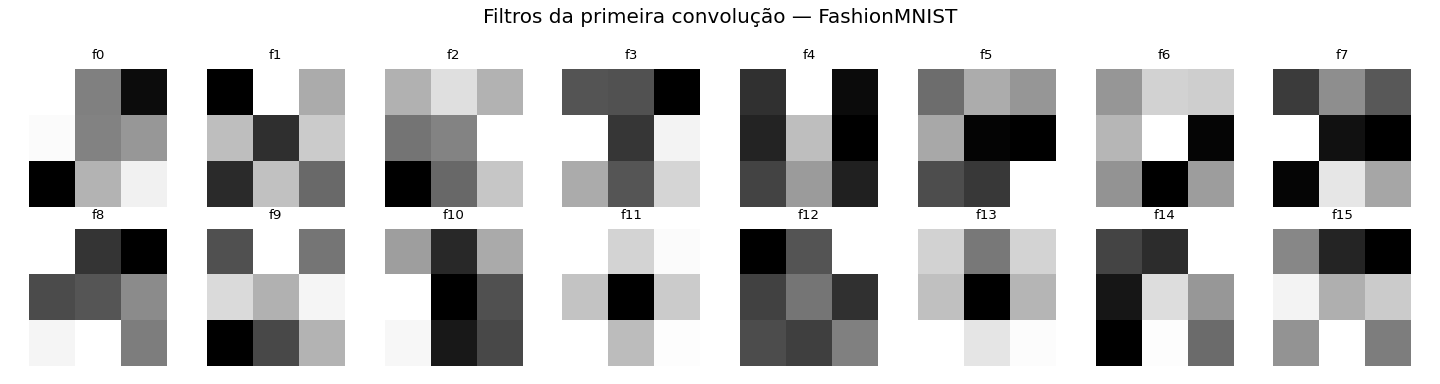

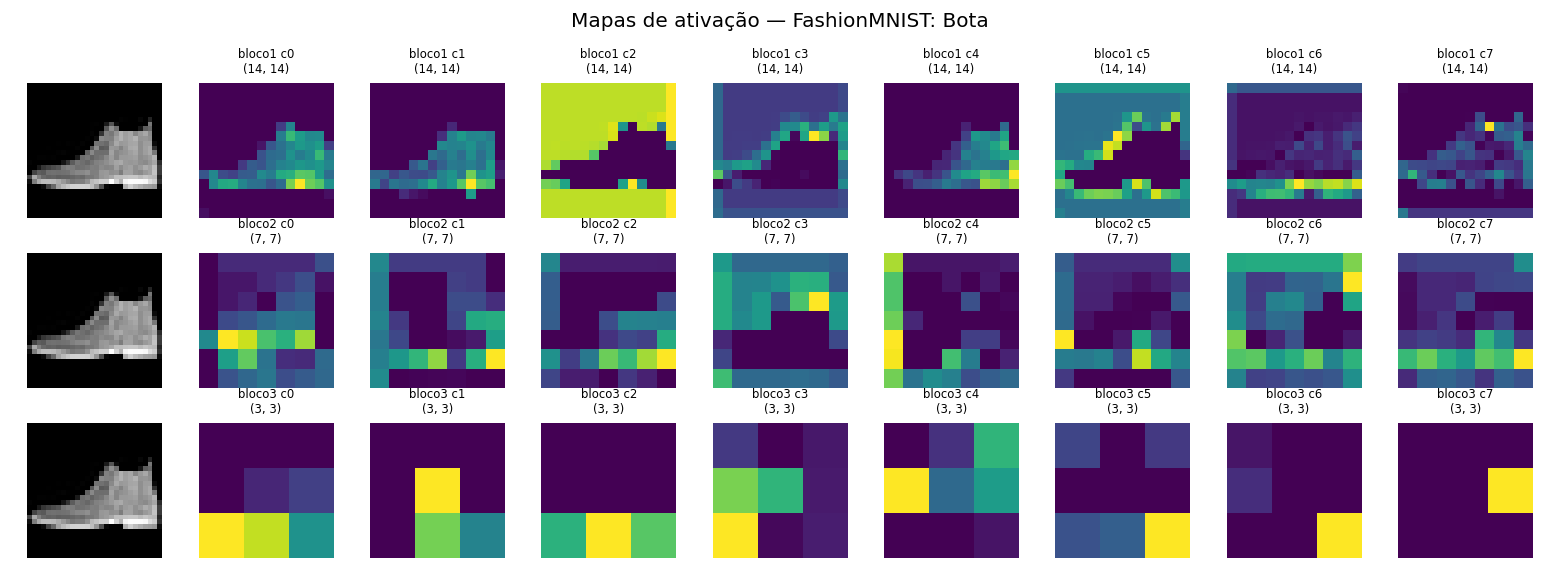

In [19]:
!python src/visualizar.py
from IPython.display import Image, display
display(Image("outputs/filtros.png")); display(Image("outputs/ativacoes.png"))

Os filtros parecem detectar bordas — metade escura e metade clara, na vertical ouhorizontal. Nos mapas a imagem vai de 14×14 até 3×3: no último bloco não dá maispara saber onde as coisas estão, só o que a rede achou.## 3.5 Robustez

## 3.5 Robustez

In [20]:
import glob
fotos = sorted(glob.glob("/content/*.jpg"))
args = " ".join(f'"{f}"' for f in fotos)
print("="*60, "\nSEM --inverter\n", "="*60)
!python src/predict.py {args}
print("\n" + "="*60, "\nCOM --inverter\n", "="*60)
!python src/predict.py {args} --inverter

SEM --inverter
usage: predict.py [-h] [--inverter] [--topk TOPK] imagens [imagens ...]
predict.py: error: the following arguments are required: imagens

COM --inverter
usage: predict.py [-h] [--inverter] [--topk TOPK] imagens [imagens ...]
predict.py: error: the following arguments are required: imagens


In [27]:
!rm -rf /content/fotos_repo
!git clone -q https://github.com/artcllgr/CNN.git /content/fotos_repo
import glob
fotos = sorted(glob.glob("/content/fotos_repo/*.jpg"))
print("fotos:", [f.split("/")[-1] for f in fotos])

fotos: ['camisa.jpg', 'shorts.jpg', 'tenis.jpg']


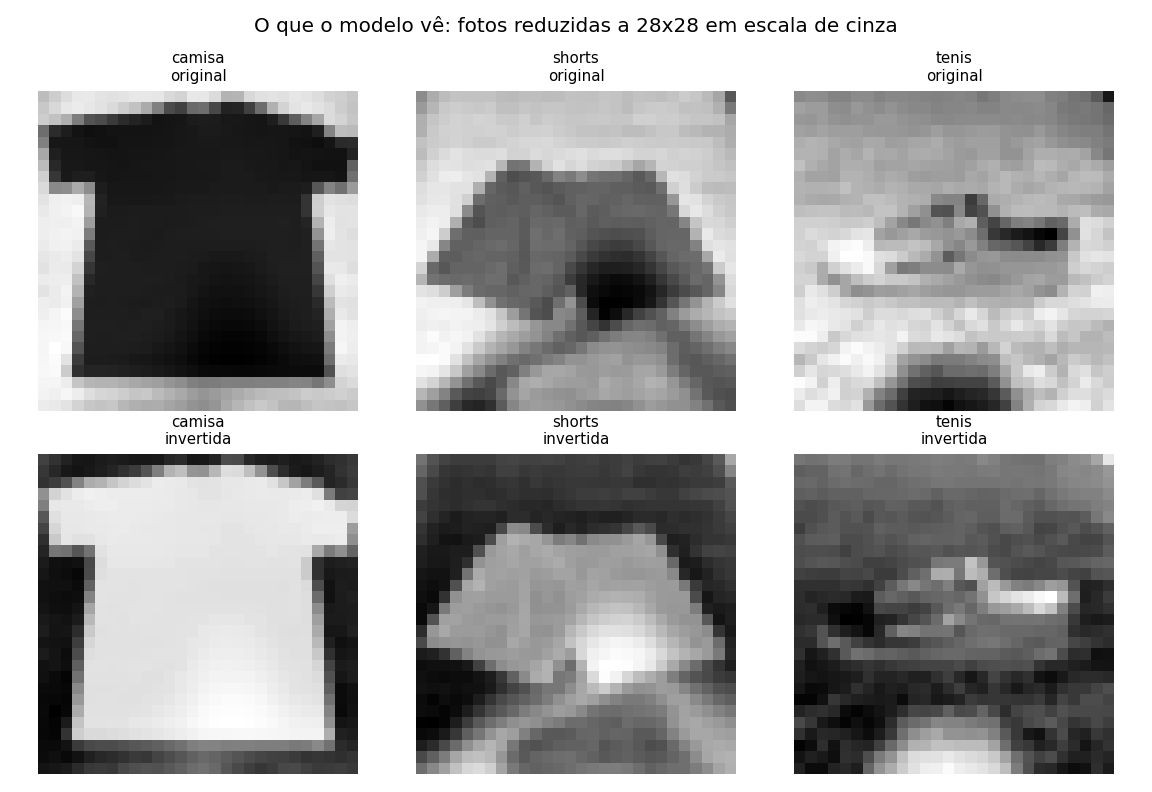

In [49]:
import sys, matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
from pathlib import Path
sys.path.insert(0, "src")
from config import CFG
from predict import preparar_imagem

fig, eixos = plt.subplots(2, len(fotos), figsize=(3.2*len(fotos), 6.6))
for j, f in enumerate(fotos):
    for i, inv in enumerate([False, True]):
        t = preparar_imagem(Path(f), inverter=inv)[0, 0]
        img = (t * CFG.desvio + CFG.media).clamp(0, 1).numpy()
        eixos[i][j].imshow(img, cmap="gray"); eixos[i][j].axis("off")
        eixos[i][j].set_title(f"{Path(f).stem}\n{'invertida' if inv else 'original'}", fontsize=9)
fig.suptitle("O que o modelo vê: fotos reduzidas a 28x28 em escala de cinza")
fig.tight_layout(); fig.savefig("outputs/fotos_28x28.png", dpi=120); plt.close(fig)
from IPython.display import Image, display
display(Image("outputs/fotos_28x28.png"))

Errou as seis vezes e quase sempre respondeu Bolsa, que é a classe de forma maisgenérica. O `--inverter` não resolveu porque o problema não é só a cor: minhasfotos têm fundo com textura e o dataset tem fundo preto puro.A acurácia de 89,74% só vale para imagens parecidas com as do treino. Fora dissoo modelo erra com confiança alta, o que é pior.

# Nível 4 — Caminho A: CIFAR-10

| Parâmetro | Fashion-MNIST | CIFAR-10 |
|---|---|---|
| Canais | 1 | 3 |
| Resolução | 28×28 | 32×32 |
| Média | 0,2860 | (0,4914 · 0,4822 · 0,4465) |
| Desvio | 0,3530 | (0,2470 · 0,2435 · 0,2616) |
| Padding `RandomCrop` | 2 | 4 |
| Flatten | 576 | 1024 |
| Parâmetros | 98.554 | 156.186 |

In [29]:
from pathlib import Path

cfg = Path("src/config.py"); s = cfg.read_text(encoding="utf-8")
s = s.replace('dataset: str = "FashionMNIST"', 'dataset: str = "CIFAR10"')
s = s.replace('tamanho_imagem: int = 28          # imagens 28x28',
              'tamanho_imagem: int = 32          # imagens 32x32')
s = s.replace('canais: int = 1                   # 1 = escala de cinza, 3 = RGB',
              'canais: int = 3                   # 1 = escala de cinza, 3 = RGB')
s = s.replace('media: float = 0.2860\n    desvio: float = 0.3530',
              'media: tuple = (0.4914, 0.4822, 0.4465)\n'
              '    desvio: tuple = (0.2470, 0.2435, 0.2616)')
s = s[:s.index("CLASSES = [")] + '''CLASSES = [
    "Avião", "Automóvel", "Pássaro", "Gato", "Veado",
    "Cachorro", "Sapo", "Cavalo", "Navio", "Caminhão",
]
'''
cfg.write_text(s, encoding="utf-8")

d = Path("src/data.py"); s = d.read_text(encoding="utf-8")
s = s.replace("datasets.FashionMNIST", "datasets.CIFAR10")
s = s.replace("transforms.Normalize((cfg.media,), (cfg.desvio,))",
              "transforms.Normalize(cfg.media, cfg.desvio)")
s = s.replace("transforms.RandomCrop(cfg.tamanho_imagem, padding=2)",
              "transforms.RandomCrop(cfg.tamanho_imagem, padding=4)")
s = s.replace("    imagens = imagens[:n] * CFG.desvio + CFG.media  # desfaz a normalização p/ visualizar",
              "    _m = torch.tensor(CFG.media).view(1, -1, 1, 1)\n"
              "    _d = torch.tensor(CFG.desvio).view(1, -1, 1, 1)\n"
              "    imagens = imagens[:n] * _d + _m  # desfaz a normalização p/ visualizar")
s = s.replace('            ax.imshow(imagens[i].squeeze().numpy(), cmap="gray")',
              '            _img = imagens[i].clamp(0, 1)\n'
              '            if _img.shape[0] == 1:\n'
              '                ax.imshow(_img.squeeze().numpy(), cmap="gray")\n'
              '            else:\n'
              '                ax.imshow(_img.permute(1, 2, 0).numpy())')
d.write_text(s, encoding="utf-8")

!git diff --stat

 2tsCPV-2/cnn/src/config.py   | 22 +++++++---------------
 2tsCPV-2/cnn/src/data.py     | 22 ++++++++++++++--------
 2tsCPV-2/cnn/src/evaluate.py | 15 +++++++++++++++
 3 files changed, 36 insertions(+), 23 deletions(-)


In [30]:
!git diff src/config.py

diff --git a/2tsCPV-2/cnn/src/config.py b/2tsCPV-2/cnn/src/config.py
index ed32422..8db0c5f 100644
--- a/2tsCPV-2/cnn/src/config.py
+++ b/2tsCPV-2/cnn/src/config.py
@@ -25,17 +25,17 @@ OUT_DIR = ROOT / "outputs"      # onde salvamos pesos, gráficos e métricas
 @dataclass
 class Config:
     # --- Dados ---------------------------------------------------------
-    dataset: str = "FashionMNIST"
-    tamanho_imagem: int = 28          # imagens 28x28
-    canais: int = 1                   # 1 = escala de cinza, 3 = RGB
+    dataset: str = "CIFAR10"
+    tamanho_imagem: int = 32          # imagens 32x32
+    canais: int = 3                   # 1 = escala de cinza, 3 = RGB
     n_classes: int = 10
     frac_validacao: float = 0.1       # 10% do treino vira validação
     num_workers: int = 0              # 0 é o mais seguro no Windows
 
     # Estatísticas do FashionMNIST (calculadas sobre o conjunto de treino).
     # Usadas para normalizar: x = (x - media) / desvio
-    media: float = 0.2

In [31]:
!python src/data.py

  0% 688k/170M [00:08<35:44, 79.2kB/s]
Traceback (most recent call last):
  File "/content/fiap/2tsCPV-2/cnn/src/data.py", line 161, in <module>
    tr, va, te, classes = obter_dataloaders(rapido=args.rapido)
                          ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^
  File "/content/fiap/2tsCPV-2/cnn/src/data.py", line 77, in obter_dataloaders
    base_treino_aug = datasets.CIFAR10(
        root=DATA_DIR, train=True, download=True, transform=t_treino)
  File "/usr/local/lib/python3.13/dist-packages/torchvision/datasets/cifar.py", line 66, in __init__
    self.download()
    ~~~~~~~~~~~~~^^
  File "/usr/local/lib/python3.13/dist-packages/torchvision/datasets/cifar.py", line 139, in download
    download_and_extract_archive(self.url, self.root, filename=self.filename, md5=self.tgz_md5)
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/torchvision/datasets/utils.py", line 388, in download_a

In [50]:
!ls outputs/

ativacoes.png	curvas_treino.png  filtros.png	    matriz_confusao.png
baseline_fm.pt	erros_teste.png    fotos_28x28.png  melhor_modelo.pt
classes.json	filtros_fm.png	   historico.json   metricas_teste.json


In [51]:
!python src/data.py

100% 170M/170M [37:09<00:00, 76.5kB/s]
Classes (10): ['Avião', 'Automóvel', 'Pássaro', 'Gato', 'Veado', 'Cachorro', 'Sapo', 'Cavalo', 'Navio', 'Caminhão']
Treino    :  45000 imagens | 352 lotes
Validação :   5000 imagens | 40 lotes
Teste     :  10000 imagens | 79 lotes

Formato do lote x: (128, 3, 32, 32)  (N, C, H, W)
Formato do lote y: (128,)  dtype=torch.int64
Faixa de valores após normalizar: [-1.99, 2.13]
[ok] Amostra salva em /content/fiap/2tsCPV-2/cnn/outputs/amostra_treino.png


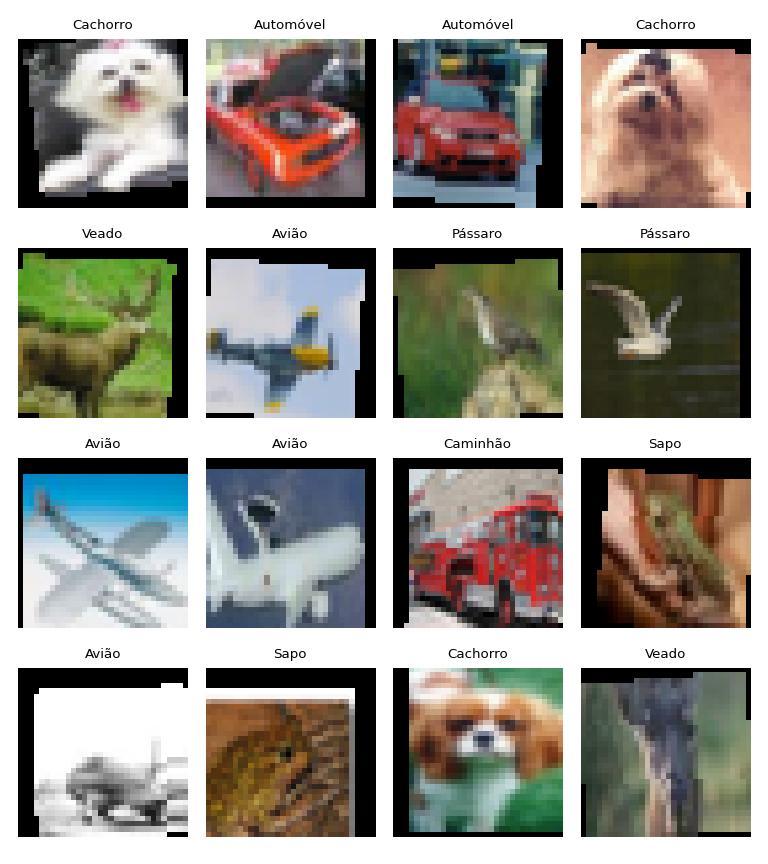

In [52]:
from IPython.display import Image, display
display(Image("outputs/amostra_treino.png"))

In [33]:
!python src/model.py

CNNSimples(
  (extrator): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)


In [34]:
!python src/train.py --epocas 12

Dispositivo: cuda

  0% 623k/170M [00:19<1:28:33, 32.0kB/s]
Traceback (most recent call last):
  File "/content/fiap/2tsCPV-2/cnn/src/train.py", line 173, in <module>
    treinar(p.parse_args())
  File "/content/fiap/2tsCPV-2/cnn/src/train.py", line 81, in treinar
    carregador_treino, carregador_val, _, classes = obter_dataloaders(CFG, rapido=args.rapido)
  File "/content/fiap/2tsCPV-2/cnn/src/data.py", line 77, in obter_dataloaders
    base_treino_aug = datasets.CIFAR10(
  File "/usr/local/lib/python3.13/dist-packages/torchvision/datasets/cifar.py", line 66, in __init__
    self.download()
  File "/usr/local/lib/python3.13/dist-packages/torchvision/datasets/cifar.py", line 139, in download
    download_and_extract_archive(self.url, self.root, filename=self.filename, md5=self.tgz_md5)
  File "/usr/local/lib/python3.13/dist-packages/torchvision/datasets/utils.py", line 388, in download_and_extract_archive
    download_url(url, download_root, filename, md5)
  File "/usr/local/lib/pytho

In [35]:
!python src/evaluate.py

Modelo da época 11 (acc. validação 90.12%)

^C


In [36]:
from pathlib import Path
p = Path("src/evaluate.py"); s = p.read_text(encoding="utf-8")
s = s.replace("        img = img.squeeze() * CFG.desvio + CFG.media",
              "        _m = torch.tensor(CFG.media).view(-1, 1, 1)\n"
              "        _d = torch.tensor(CFG.desvio).view(-1, 1, 1)\n"
              "        img = (img * _d + _m).clamp(0, 1)")
p.write_text(s, encoding="utf-8")
!sed -n '120,140p' src/evaluate.py

    if not erros:
        return
    erros.sort(key=lambda e: -e[0])   # os mais confiantes primeiro
    erros = erros[:n]

    linhas, colunas = 3, (n + 2) // 3
    fig, eixos = plt.subplots(linhas, colunas, figsize=(colunas * 1.9, linhas * 2.2))
    for ax, (conf, img, verdadeiro, previsto) in zip(eixos.ravel(), erros):
        _m = torch.tensor(CFG.media).view(-1, 1, 1)
        _d = torch.tensor(CFG.desvio).view(-1, 1, 1)
        img = (img * _d + _m).clamp(0, 1)
        ax.imshow(img.numpy(), cmap="gray")
        ax.set_title(f"real: {classes[verdadeiro]}\nprev: {classes[previsto]} ({conf:.0%})",
                     fontsize=7, color="darkred")
    for ax in eixos.ravel():
        ax.axis("off")
    fig.suptitle("Erros com maior confiança", fontsize=11)
    fig.tight_layout()
    fig.savefig(caminho, dpi=120)
    plt.close(fig)
    print(f"[ok] Erros salvos em {caminho}")


In [37]:
from pathlib import Path
p = Path("src/evaluate.py"); s = p.read_text(encoding="utf-8")
s = s.replace('        ax.imshow(img.numpy(), cmap="gray")',
              '        if img.shape[0] == 1:\n'
              '            ax.imshow(img.squeeze().numpy(), cmap="gray")\n'
              '        else:\n'
              '            ax.imshow(img.permute(1, 2, 0).numpy())')
p.write_text(s, encoding="utf-8")
print("corrigido")
!python src/evaluate.py

corrigido
Modelo da época 11 (acc. validação 90.12%)

Traceback (most recent call last):
  File "/content/fiap/2tsCPV-2/cnn/src/evaluate.py", line 201, in <module>
    avaliar(p.parse_args().rapido)
  File "/content/fiap/2tsCPV-2/cnn/src/evaluate.py", line 168, in avaliar
    _, _, carregador_teste, _ = obter_dataloaders(CFG, rapido=rapido)
  File "/content/fiap/2tsCPV-2/cnn/src/data.py", line 77, in obter_dataloaders
    base_treino_aug = datasets.CIFAR10(
  File "/usr/local/lib/python3.13/dist-packages/torchvision/datasets/cifar.py", line 66, in __init__
    self.download()
  File "/usr/local/lib/python3.13/dist-packages/torchvision/datasets/cifar.py", line 139, in download
    download_and_extract_archive(self.url, self.root, filename=self.filename, md5=self.tgz_md5)
  File "/usr/local/lib/python3.13/dist-packages/torchvision/datasets/utils.py", line 388, in download_and_extract_archive
    download_url(url, download_root, filename, md5)
  File "/usr/local/lib/python3.13/dist-packag


=== matriz_confusao.png ===


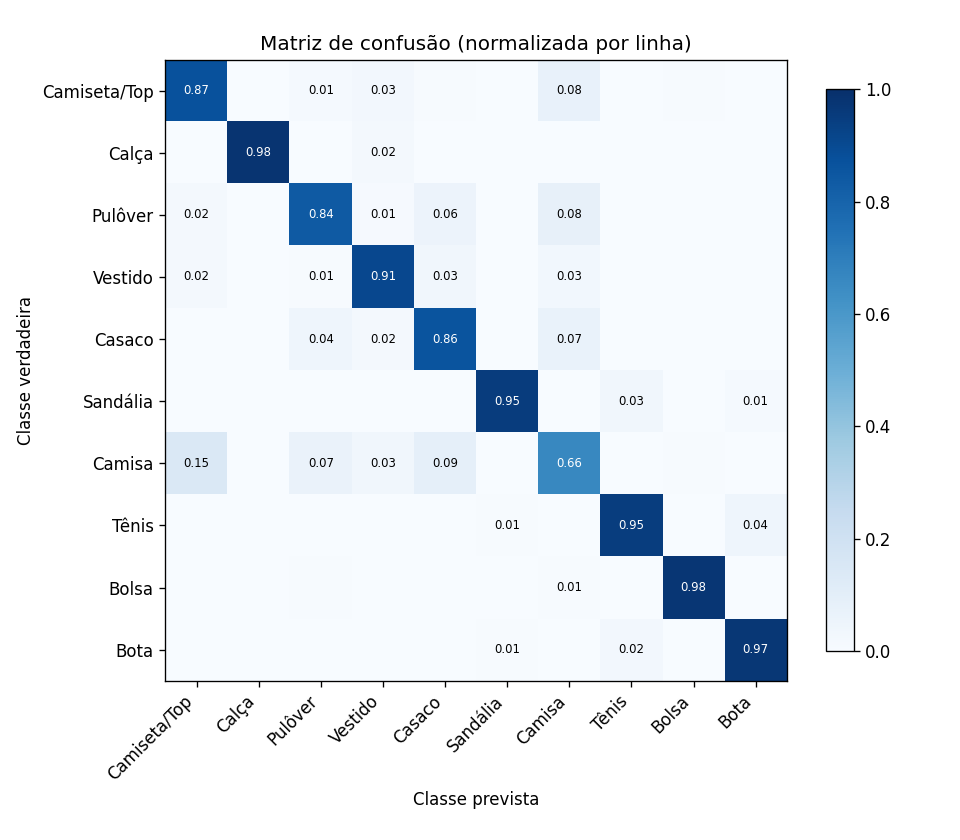


=== erros_teste.png ===


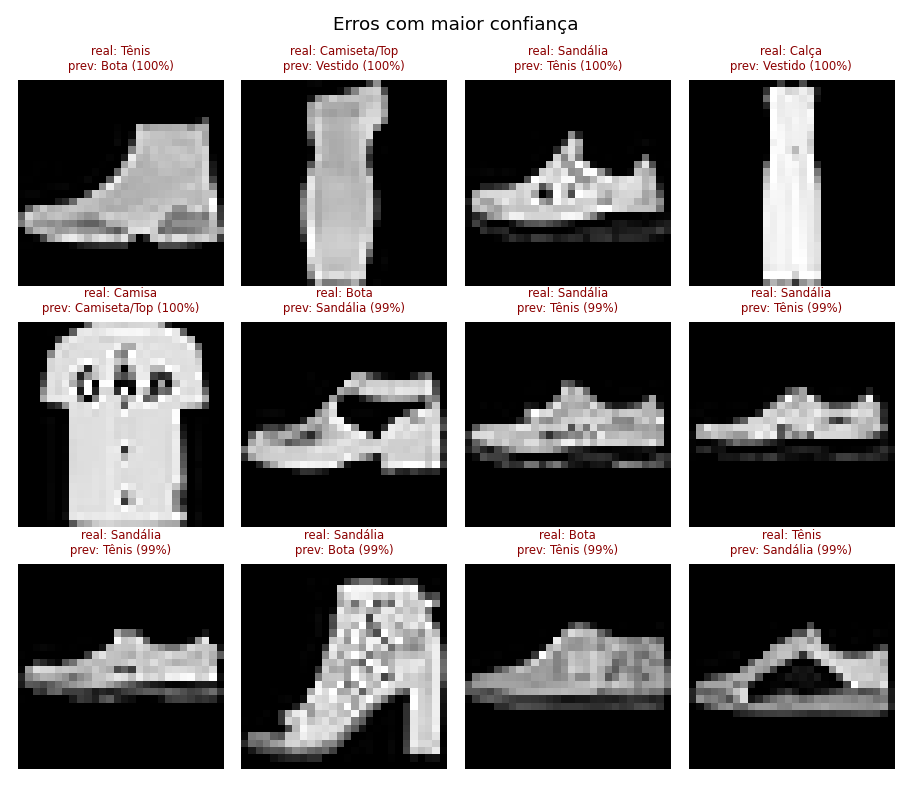


=== curvas_treino.png ===


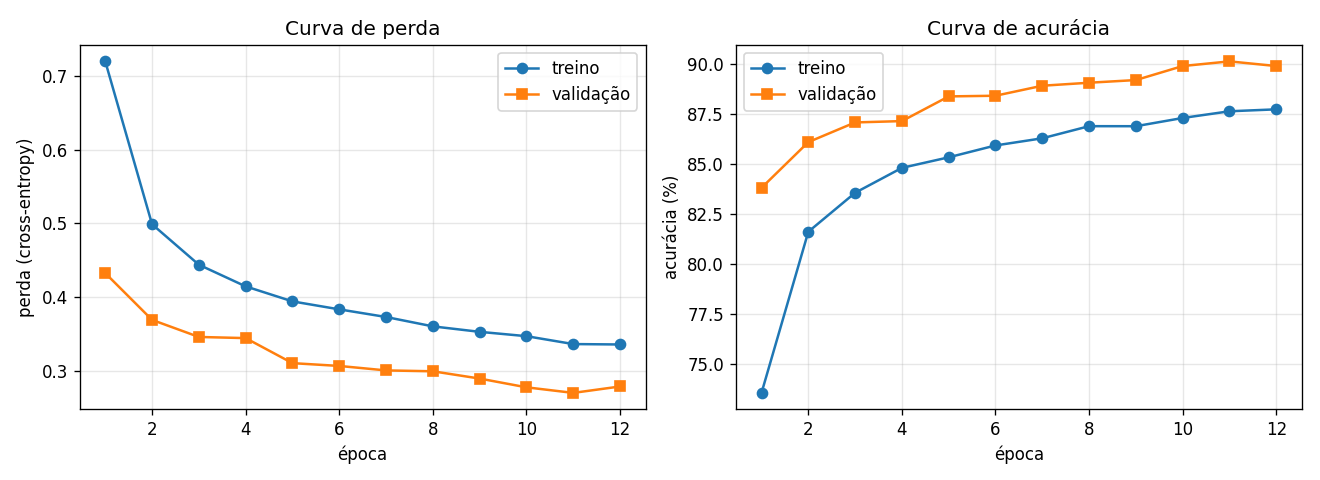

In [38]:
from IPython.display import Image, display
for f in ["matriz_confusao.png", "erros_teste.png", "curvas_treino.png"]:
    print(f"\n=== {f} ===")
    display(Image(f"outputs/{f}"))

In [39]:
import json
m = json.load(open("outputs/metricas_teste.json"))
mat, classes = m["matriz_confusao"], m["classes"]
pares = [(mat[i][j], classes[i], classes[j])
         for i in range(10) for j in range(10) if i != j]
pares.sort(reverse=True)
for n, v, p_ in pares[:8]:
    print(f"  {n:>4}  {v:<14} -> {p_}")

   146  Camisa         -> Camiseta/Top
    86  Camisa         -> Casaco
    79  Pulôver        -> Camisa
    78  Camiseta/Top   -> Camisa
    70  Casaco         -> Camisa
    66  Camisa         -> Pulôver
    57  Pulôver        -> Casaco
    45  Tênis          -> Bota


Teste: **71,67%** — queda de 18 pontos mesmo com o modelo 58% maior.Esperava overfitting, mas as duas curvas continuaram subindo até a época 12: éunderfitting, o treino parou por falta de tempo.As piores classes são animais (Gato F1 0,51) e as melhores são veículos(Automóvel 0,84). Nos erros mais confiantes, pássaro no céu virou avião e aviãosobre água virou navio — o modelo está usando o fundo como atalho.



## Os mesmos experimentos no CIFAR-10

In [53]:
import json, re, subprocess, time, shutil
from pathlib import Path

CFG_P, DATA_P = Path("src/config.py"), Path("src/data.py")
CFG0, DATA0 = CFG_P.read_text(encoding="utf-8"), DATA_P.read_text(encoding="utf-8")
Path("experimentos").mkdir(exist_ok=True)

def rodar(nome, args=None, patch_cfg=None, patch_data=None):
    CFG_P.write_text(patch_cfg(CFG0) if patch_cfg else CFG0, encoding="utf-8")
    DATA_P.write_text(patch_data(DATA0) if patch_data else DATA0, encoding="utf-8")
    t0 = time.time()
    r = subprocess.run(["python", "src/train.py", "--epocas", "5"] + (args or []),
                       capture_output=True, text=True)
    dur = time.time() - t0
    saida = r.stdout + r.stderr
    mp = re.search(r"Parâmetros treináveis: ([\d,]+)", saida)
    params = mp.group(1) if mp else "?"
    try:
        h = json.loads(Path("outputs/historico.json").read_text(encoding="utf-8"))
        val = h["melhor_val_acc"] * 100
        tr_f = h["historico"]["train_acc"][-1] * 100
        vl_f = h["historico"]["val_acc"][-1] * 100
        shutil.copy("outputs/historico.json", f"experimentos/hist_{nome}.json")
    except Exception:
        val = tr_f = vl_f = float("nan")
        print(f"--- falha em {nome} ---\n{saida[-1200:]}")
    CFG_P.write_text(CFG0, encoding="utf-8")
    DATA_P.write_text(DATA0, encoding="utf-8")
    print(f"{nome:<24} melhor_val {val:6.2f}% | treino_fim {tr_f:6.2f}% | "
          f"val_fim {vl_f:6.2f}% | {params:>8} params | {dur/5:4.0f}s/ep")
    return dict(nome=nome, val=val, tr=tr_f, vl=vl_f, params=params, s=dur/5)

sem_aug   = lambda s: "\n".join(l for l in s.split("\n") if "transforms.Random" not in l)
mais_cap  = lambda s: s.replace("canais_conv: tuple = (16, 32, 64)",
                                "canais_conv: tuple = (32, 64, 128)")
menos_cap = lambda s: s.replace("canais_conv: tuple = (16, 32, 64)",
                                "canais_conv: tuple = (8, 16, 32)")

res = []
res.append(rodar("baseline"))
res.append(rodar("lr_1e-1",   args=["--lr", "1e-1"]))
res.append(rodar("lr_1e-5",   args=["--lr", "1e-5"]))
res.append(rodar("sem_aug",   patch_data=sem_aug))
res.append(rodar("cap_maior", patch_cfg=mais_cap))
res.append(rodar("cap_menor", patch_cfg=menos_cap))

print("\n\n| Experimento | Melhor val | Treino (fim) | Val (fim) | Gap | Parâmetros | s/época |")
print("|---|---|---|---|---|---|---|")
for r in res:
    print(f"| {r['nome']} | {r['val']:.2f}% | {r['tr']:.2f}% | {r['vl']:.2f}% | "
          f"{r['vl']-r['tr']:+.2f} | {r['params']} | {r['s']:.0f} |")

json.dump(res, open("experimentos/resumo.json", "w"), ensure_ascii=False, indent=2)

baseline                 melhor_val  65.02% | treino_fim  58.68% | val_fim  65.02% |  156,186 params |   24s/ep
lr_1e-1                  melhor_val  19.62% | treino_fim  17.38% | val_fim  19.10% |  156,186 params |   20s/ep
lr_1e-5                  melhor_val  34.90% | treino_fim  30.29% | val_fim  34.90% |  156,186 params |   25s/ep
sem_aug                  melhor_val  71.30% | treino_fim  68.50% | val_fim  71.30% |  156,186 params |   15s/ep
cap_maior                melhor_val  71.48% | treino_fim  62.60% | val_fim  71.48% |  357,034 params |   25s/ep
cap_menor                melhor_val  58.90% | treino_fim  52.10% | val_fim  58.90% |   73,042 params |   24s/ep


| Experimento | Melhor val | Treino (fim) | Val (fim) | Gap | Parâmetros | s/época |
|---|---|---|---|---|---|---|
| baseline | 65.02% | 58.68% | 65.02% | +6.34 | 156,186 | 24 |
| lr_1e-1 | 19.62% | 17.38% | 19.10% | +1.72 | 156,186 | 20 |
| lr_1e-5 | 34.90% | 30.29% | 34.90% | +4.61 | 156,186 | 25 |
| sem_aug | 71.30% | 68.

In [54]:
import json, re, subprocess, time, shutil
from pathlib import Path

CFG_P, DATA_P, MOD_P = Path("src/config.py"), Path("src/data.py"), Path("src/model.py")
CFG0, DATA0, MOD0 = (p.read_text(encoding="utf-8") for p in (CFG_P, DATA_P, MOD_P))
Path("experimentos").mkdir(exist_ok=True)

def rodar(nome, args=None, pc=None, pd=None, pm=None):
    CFG_P.write_text(pc(CFG0) if pc else CFG0, encoding="utf-8")
    DATA_P.write_text(pd(DATA0) if pd else DATA0, encoding="utf-8")
    MOD_P.write_text(pm(MOD0) if pm else MOD0, encoding="utf-8")
    t0 = time.time()
    r = subprocess.run(["python", "src/train.py", "--epocas", "5"] + (args or []),
                       capture_output=True, text=True)
    dur = time.time() - t0
    mp = re.search(r"Parâmetros treináveis: ([\d,]+)", r.stdout + r.stderr)
    params = mp.group(1) if mp else "?"
    try:
        h = json.loads(Path("outputs/historico.json").read_text(encoding="utf-8"))
        val, tr, vl = h["melhor_val_acc"]*100, h["historico"]["train_acc"][-1]*100, h["historico"]["val_acc"][-1]*100
        ep1 = h["historico"]["val_acc"][0]*100
        shutil.copy("outputs/historico.json", f"experimentos/hist_{nome}.json")
    except Exception:
        val = tr = vl = ep1 = float("nan")
        print(f"--- falha em {nome} ---\n{(r.stdout+r.stderr)[-1500:]}")
    for p, o in ((CFG_P, CFG0), (DATA_P, DATA0), (MOD_P, MOD0)):
        p.write_text(o, encoding="utf-8")
    print(f"{nome:<18} val {val:6.2f}% | ep1 {ep1:6.2f}% | treino_fim {tr:6.2f}% | "
          f"gap {vl-tr:+6.2f} | {params:>8} par | {dur/5:4.0f}s/ep")
    return dict(nome=nome, val=val, ep1=ep1, tr=tr, vl=vl, params=params, s=dur/5)

sem_norm = lambda s: "\n".join(l for l in s.split("\n") if "transforms.Normalize" not in l)
drop0    = lambda s: s.replace("dropout: float = 0.3", "dropout: float = 0.0")
drop7    = lambda s: s.replace("dropout: float = 0.3", "dropout: float = 0.7")
sem_bn   = lambda s: re.sub(r"\n\s*nn\.BatchNorm2d\([^)]*\),", "", s)

res = []
res.append(rodar("sem_norm",   pd=sem_norm))
res.append(rodar("dropout_0.0", pc=drop0))
res.append(rodar("dropout_0.7", pc=drop7))
res.append(rodar("sem_bn",     pm=sem_bn))
res.append(rodar("sem_bn_lr1e-2", pm=sem_bn, args=["--lr", "1e-2"]))

print("\n| Experimento | Melhor val | Época 1 | Treino (fim) | Gap | Parâmetros | s/ep |")
print("|---|---|---|---|---|---|---|")
for r in res:
    print(f"| {r['nome']} | {r['val']:.2f}% | {r['ep1']:.2f}% | {r['tr']:.2f}% | "
          f"{r['vl']-r['tr']:+.2f} | {r['params']} | {r['s']:.0f} |")

json.dump(res, open("experimentos/resumo2.json", "w"), ensure_ascii=False, indent=2)

sem_norm           val  60.52% | ep1  49.94% | treino_fim  58.54% | gap  +1.98 |  156,186 par |   19s/ep
dropout_0.0        val  68.40% | ep1  56.48% | treino_fim  65.58% | gap  +2.28 |  156,186 par |   25s/ep
dropout_0.7        val  51.74% | ep1  38.60% | treino_fim  42.42% | gap  +9.32 |  156,186 par |   25s/ep
sem_bn             val  59.38% | ep1  45.54% | treino_fim  54.00% | gap  +5.38 |  155,962 par |   25s/ep
sem_bn_lr1e-2      val  35.72% | ep1  29.92% | treino_fim  29.74% | gap  +5.98 |  155,962 par |   24s/ep

| Experimento | Melhor val | Época 1 | Treino (fim) | Gap | Parâmetros | s/ep |
|---|---|---|---|---|---|---|
| sem_norm | 60.52% | 49.94% | 58.54% | +1.98 | 156,186 | 19 |
| dropout_0.0 | 68.40% | 56.48% | 65.58% | +2.28 | 156,186 | 25 |
| dropout_0.7 | 51.74% | 38.60% | 42.42% | +9.32 | 156,186 | 25 |
| sem_bn | 59.38% | 45.54% | 54.00% | +5.38 | 155,962 | 25 |
| sem_bn_lr1e-2 | 35.72% | 29.92% | 29.74% | +5.98 | 155,962 | 24 |


Aumentar a capacidade rendeu +5,18 pp no CIFAR-10 contra +1,03 no Fashion-MNIST,o que confirma o underfitting. A normalização também importa mais aqui(−4,08 pp contra −0,24), o que faz sentido com três canais de cores.## Deploy

In [55]:
!python src/export_model.py

Traceback (most recent call last):
  File "/content/fiap/2tsCPV-2/cnn/src/export_model.py", line 94, in <module>
    modelo, ckpt = carregar_checkpoint(dispositivo)
                   ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^
  File "/content/fiap/2tsCPV-2/cnn/src/evaluate.py", line 45, in carregar_checkpoint
    modelo.load_state_dict(ckpt["model_state"])
    ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/torch/nn/modules/module.py", line 2639, in load_state_dict
    raise RuntimeError(
    ...<3 lines>...
    )
RuntimeError: Error(s) in loading state_dict for CNNSimples:
	Missing key(s) in state_dict: "extrator.0.1.weight", "extrator.0.1.bias", "extrator.0.1.running_mean", "extrator.0.1.running_var", "extrator.1.1.weight", "extrator.1.1.bias", "extrator.1.1.running_mean", "extrator.1.1.running_var", "extrator.2.1.weight", "extrator.2.1.bias", "extrator.2.1.running_mean", "extrator.2.1.running_var". 


O `api.py` refaz o pré-processamento sem torchvision. O `tobytes()` devolve(H, W, C) e o PyTorch espera (C, H, W) — um `reshape` direto não dá erro, sóembaralha os canais em silêncio.

In [56]:
from pathlib import Path
a = Path("deploy/api.py"); s = a.read_text(encoding="utf-8")

s = s.replace("TAMANHO = 28\nMEDIA = 0.2860\nDESVIO = 0.3530",
              "TAMANHO = 32\n"
              "# Estatísticas por canal RGB do conjunto de treino do CIFAR-10.\n"
              "MEDIA = torch.tensor([0.4914, 0.4822, 0.4465]).view(1, 3, 1, 1)\n"
              "DESVIO = torch.tensor([0.2470, 0.2435, 0.2616]).view(1, 3, 1, 1)")

s = s.replace('imagem = Image.open(io.BytesIO(bytes_imagem)).convert("L")',
              'imagem = Image.open(io.BytesIO(bytes_imagem)).convert("RGB")')

s = s.replace(
    "    tensor = bruto.float().reshape(1, 1, TAMANHO, TAMANHO) / 255.0  # = ToTensor()",
    "    # ATENÇÃO: tobytes() devolve os canais INTERCALADOS no formato (H, W, C).\n"
    "    # O PyTorch espera (C, H, W). Um reshape(1, 3, H, W) direto NÃO gera erro,\n"
    "    # apenas embaralha os canais em silêncio e derruba a acurácia.\n"
    "    tensor = (bruto.float().reshape(TAMANHO, TAMANHO, 3)\n"
    "                  .permute(2, 0, 1).unsqueeze(0) / 255.0)  # = ToTensor()")

a.write_text(s, encoding="utf-8")
!sed -n '40,50p;82,98p' deploy/api.py



# --- constantes que PRECISAM bater com o treino ----------------------------
TAMANHO = 32
# Estatísticas por canal RGB do conjunto de treino do CIFAR-10.
MEDIA = torch.tensor([0.4914, 0.4822, 0.4465]).view(1, 3, 1, 1)
DESVIO = torch.tensor([0.2470, 0.2435, 0.2616]).view(1, 3, 1, 1)

RAIZ = Path(__file__).resolve().parents[1]
CAMINHO_MODELO = RAIZ / "outputs" / "modelo_scriptado.pt"
CAMINHO_CLASSES = RAIZ / "outputs" / "classes.json"


def preprocessar(bytes_imagem: bytes, inverter: bool = False) -> torch.Tensor:
    """bytes -> tensor (1,1,28,28). Mesma receita do treino, sem torchvision."""
    imagem = Image.open(io.BytesIO(bytes_imagem)).convert("RGB")
    if inverter:
        imagem = ImageOps.invert(imagem)
    imagem = imagem.resize((TAMANHO, TAMANHO))

    # bytearray (e não bytes) porque torch.frombuffer exige um buffer gravável
    bruto = torch.frombuffer(bytearray(imagem.tobytes()), dtype=torch.uint8)
    # ATENÇÃO: tobytes() devolve os canais INTERCALADOS no formato (H, W

In [57]:
!pip install -q fastapi "uvicorn[standard]" python-multipart

import subprocess, time, urllib.request, json
proc = subprocess.Popen(
    ["python", "-m", "uvicorn", "deploy.api:app", "--host", "127.0.0.1", "--port", "8000"],
    cwd="/content/fiap/2tsCPV-2/cnn",
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True,
)
time.sleep(15)
try:
    print(json.loads(urllib.request.urlopen("http://127.0.0.1:8000/saude").read()))
except Exception as erro:
    print("falhou:", erro)
    proc.terminate(); print(proc.stdout.read()[-2000:])

falhou: <urlopen error [Errno 111] Connection refused>
INFO:     Started server process [42956]
INFO:     Waiting for application startup.
ERROR:    Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/starlette/routing.py", line 648, in lifespan
    async with self.lifespan_context(app) as maybe_state:
               ~~~~~~~~~~~~~~~~~~~~~^^^^^
  File "/usr/lib/python3.13/contextlib.py", line 214, in __aenter__
    return await anext(self.gen)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/content/fiap/2tsCPV-2/cnn/deploy/api.py", line 64, in ciclo_de_vida
    raise RuntimeError(
        f"Modelo não encontrado em {CAMINHO_MODELO}.\n"
        "Rode antes:  python src/train.py  e  python src/export_model.py")
RuntimeError: Modelo não encontrado em /content/fiap/2tsCPV-2/cnn/outputs/modelo_scriptado.pt.
Rode antes:  python src/train.py  e  python src/export_model.py

ERROR:    Application startup failed. Exiting.



In [58]:
from pathlib import Path
t = Path("deploy/testar_api.py"); s = t.read_text(encoding="utf-8")
s = s.replace("datasets.FashionMNIST", "datasets.CIFAR10")
t.write_text(s, encoding="utf-8")
!grep -n "datasets\." deploy/testar_api.py
!python deploy/testar_api.py --n 20

66:    conjunto_teste = datasets.CIFAR10(root=DATA_DIR, train=False, download=True)
[erro] servidor não respondeu em http://127.0.0.1:8000: <urlopen error [Errno 111] Connection refused>
Suba o servidor com:  python -m uvicorn deploy.api:app --port 8000


| Verificação | Fashion-MNIST | CIFAR-10 |
|---|---|---|
| Export (diferença) | 3,34e-06 | 9,54e-07 |
| `testar_api.py` (20 img) | 18/20 | 17/20 |
| Latência média | 3,4 ms | 4,2 ms |

A acurácia da API bate com a do `evaluate.py`, o que mostra que o pré-processamento está equivalente. Se os canais estivessem trocados daria uns 20 ou 30%.

# Conclusão

A acurácia caiu 18 pontos mesmo com o modelo 58% maior, então o gargalo não era tamanho de rede. O CIFAR-10 é mais difícil porque a mesma classe varia muito (um gato em qualquer pose), o fundo engana em vez de ajudar, e as classes se distinguem por significado e não por formato.

O que mais me surpreendeu foi ver que o modelo aprendeu a usar o fundo como pista. Mas ele não está tão perdido: no top-2 chega a 87,53%.

Se fosse continuar, tentaria mais épocas primeiro, depois mais capacidade.